# Stage 6: Exploratory Data Analysis, Statistics and Plotting

## Objective

The goal of this stage is to explore the cleaned FSA dataset stored in PostgreSQL and identify patterns, distributions, missing values, geographic characteristics, and relationships that may be useful for later feature engineering and machine learning.

This stage focuses on understanding the data rather than building predictive models.

The analysis will use the cleaned Silver table:

`silver.fsa_establishments_clean`

In [2]:
# Pandas is used for loading, exploring, and analysing tabular data
import pandas as pd

# psycopg2 is used to connect Python to PostgreSQL
import psycopg2


# Connect to the PostgreSQL database
connection = psycopg2.connect(
    host="host.docker.internal",
    port=5433,
    database="food_hygiene",
    user="postgres",
    password="postgres"
)


# SQL query to retrieve the cleaned Silver dataset
query = """
SELECT *
FROM silver.fsa_establishments_clean;
"""


# Load the PostgreSQL result into a Pandas DataFrame
df = pd.read_sql_query(query, connection)


# Close the database connection
connection.close()


# Check the size of the dataset
print(df.shape)

# Preview the first 5 rows
df.head()

(100, 26)


/tmp/ipykernel_15/3049728439.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,bronze_id,address_line1,address_line2,address_line3,business_name,business_type,business_type_id,changes_by_server_id,fhrsid,local_authority_business_id,...,rating_date,rating_key,rating_value,scheme_type,latitude,longitude,hygiene,structural,confidence_in_management,ingested_at
0,1,NaN,NaN,NaN,(ki:ts),Retailers - other,4613,0,1916465,LKNM9H-V40BYF-WAVKXY,...,2026-03-04,fhrs_5_en-gb,5,FHRS,NaN,NaN,0.0,0.0,0.0,2026-08-25 00:22:06.240909+00:00
1,2,NaN,NaN,NaN,*Eatlife,Other catering premises,7841,0,1301468,20/00541/COMM,...,2025-04-17,fhrs_5_en-gb,5,FHRS,NaN,NaN,0.0,0.0,0.0,2026-08-25 00:22:06.240909+00:00
2,3,3 BERKELEY STREET,NaN,LONDON,1 Hotel Mayfair,Restaurant/Cafe/Canteen,1,0,1688813,GL6QH0-M4M5Q6-S02TKX,...,2026-01-21,fhrs_5_en-gb,5,FHRS,51.507648,-0.142200,5.0,0.0,5.0,2026-08-25 00:22:06.240909+00:00
3,4,1-4 LEICESTER SQUARE,NaN,LONDON,1 Leicester Square Rooftop Bar and Restaurant,Restaurant/Cafe/Canteen,1,0,1898862,HQ202C-1TV3G5-ZN9YQ3,...,2026-01-09,fhrs_5_en-gb,5,FHRS,51.510837,-0.130671,5.0,5.0,0.0,2026-08-25 00:22:06.240909+00:00
4,5,1 WARWICK STREET,NaN,LONDON,1 Warwick,Restaurant/Cafe/Canteen,1,0,1559410,22/00661/COMM,...,2025-04-29,fhrs_5_en-gb,5,FHRS,51.510717,-0.137291,0.0,0.0,0.0,2026-08-25 00:22:06.240909+00:00


## Step 3: Inspect the Silver Dataset

Before analysing patterns, we first inspect the structure of the cleaned dataset.

We will check:

- number of rows and columns
- column names
- data types
- non-null values
- basic dataset structure

In [3]:
# Show the number of rows and columns
print("Shape:", df.shape)

# Show all column names
print("\nColumns:")
print(df.columns.tolist())

# Show data types and non-null counts
print("\nDataset information:")
df.info()

Shape: (100, 26)

Columns:
['bronze_id', 'address_line1', 'address_line2', 'address_line3', 'business_name', 'business_type', 'business_type_id', 'changes_by_server_id', 'fhrsid', 'local_authority_business_id', 'local_authority_code', 'local_authority_email_address', 'local_authority_name', 'local_authority_website', 'new_rating_pending', 'postcode', 'rating_date', 'rating_key', 'rating_value', 'scheme_type', 'latitude', 'longitude', 'hygiene', 'structural', 'confidence_in_management', 'ingested_at']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   bronze_id                      100 non-null    int64              
 1   address_line1                  97 non-null     str                
 2   address_line2                  3 non-null      str                
 3   address_line3 

## Step 4: Analyse Missing Values

Missing values can affect statistical analysis, visualisations, feature engineering, and machine learning.

We will calculate the number and percentage of missing values in each column to understand how complete the cleaned Silver dataset is.

In [4]:
# Count missing values in each column
missing_count = df.isna().sum()

# Calculate the percentage of rows missing in each column
missing_percentage = (df.isna().mean() * 100).round(2)

# Combine the results into one table
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

# Show only columns that contain missing values
missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    by="missing_count",
    ascending=False
)

,missing_count,missing_percentage
address_line2,97,97.0
latitude,6,6.0
longitude,6,6.0
address_line1,3,3.0
address_line3,3,3.0
hygiene,3,3.0
structural,3,3.0
confidence_in_management,3,3.0
postcode,1,1.0


## Step 5: Descriptive Statistics

Descriptive statistics provide a quick summary of the numerical variables in the Silver dataset.

We will examine values such as:

- count
- mean
- standard deviation
- minimum
- maximum
- quartiles

This helps identify unusual values and understand the general distribution of the numerical features.

In [5]:
df.describe()

,bronze_id,business_type_id,changes_by_server_id,fhrsid,rating_date,latitude,longitude,hygiene,structural,confidence_in_management
count,100.000000,100.000000,100.0,1.000000e+02,100,94.000000,94.000000,97.000000,97.000000,97.000000
mean,50.500000,2357.980000,0.0,1.125934e+06,2025-01-03 20:09:36,51.566644,-0.179380,2.164948,3.247423,2.371134
min,1.000000,1.000000,0.0,4.107930e+05,2018-03-20 00:00:00,51.493090,-2.998762,0.000000,0.000000,0.000000
25%,25.750000,1.000000,0.0,4.141365e+05,2024-05-13 00:00:00,51.508428,-0.162068,0.000000,0.000000,0.000000
50%,50.500000,1.000000,0.0,1.261233e+06,2025-04-22 12:00:00,51.513064,-0.143601,0.000000,5.000000,0.000000
75%,75.250000,4613.000000,0.0,1.718003e+06,2025-11-16 00:00:00,51.516246,-0.133930,5.000000,5.000000,5.000000
max,100.000000,7845.000000,0.0,1.918174e+06,2026-07-25 00:00:00,56.674451,-0.115084,5.000000,5.000000,5.000000
std,29.011492,3354.407735,0.0,6.053132e+05,NaN,0.532556,0.294625,2.490316,2.398050,2.509646


## Step 6: Analyse Business Types

We now examine how the establishments are distributed across different business types.

This helps us understand which types of food businesses are most common in the current sample.

Later, once we have a larger dataset with different hygiene ratings, we can compare business type with hygiene risk.

In [6]:
# Count how many establishments belong to each business type
business_type_counts = df["business_type"].value_counts()

business_type_counts

business_type
Restaurant/Cafe/Canteen                  65
Retailers - other                        12
Other catering premises                   6
Hotel/bed & breakfast/guest house         6
Pub/bar/nightclub                         4
School/college/university                 3
Takeaway/sandwich shop                    3
Retailers - supermarkets/hypermarkets     1
Name: count, dtype: int64

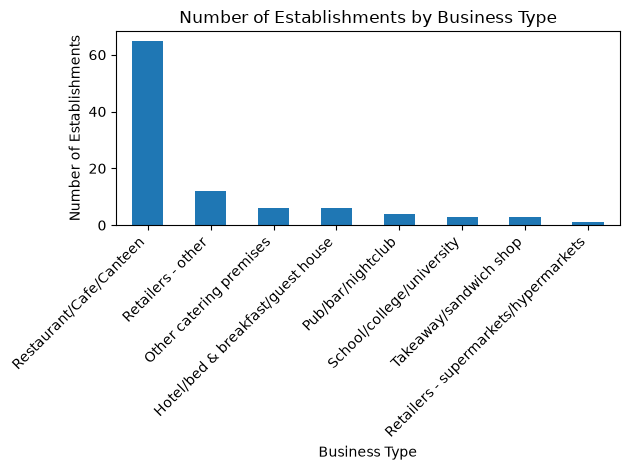

In [7]:
# Matplotlib is used to create charts and visualisations
import matplotlib.pyplot as plt

# Plot the number of establishments by business type
business_type_counts.plot(
    kind="bar"
)

plt.title("Number of Establishments by Business Type")
plt.xlabel("Business Type")
plt.ylabel("Number of Establishments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Step 7: Analyse Hygiene Rating Distribution

The hygiene rating is the main outcome we eventually want to predict.

We will first examine how the ratings are distributed in the current sample.

This also helps identify whether the sample contains enough variation for meaningful statistical analysis and machine learning.

In [8]:
# Count how many establishments have each hygiene rating
rating_counts = df["rating_value"].value_counts().sort_index()

rating_counts

rating_value
5    100
Name: count, dtype: int64

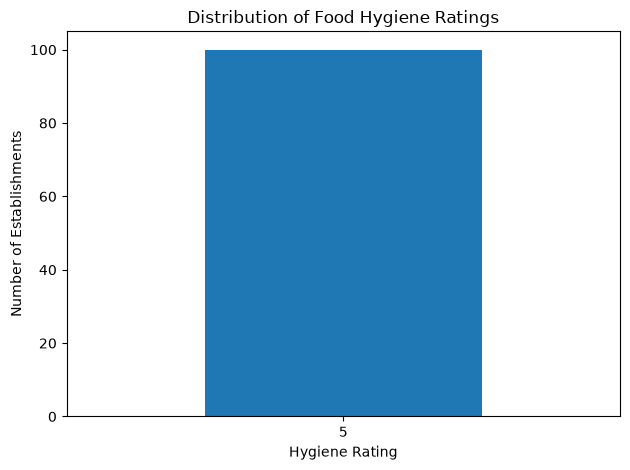

In [9]:
# Plot the distribution of hygiene ratings
rating_counts.plot(
    kind="bar"
)

plt.title("Distribution of Food Hygiene Ratings")
plt.xlabel("Hygiene Rating")
plt.ylabel("Number of Establishments")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Step 8: Analyse Inspection Scores

The FSA dataset contains three inspection score components:

- Hygiene
- Structural
- Confidence in Management

These scores provide additional information about inspection performance.

We will examine their distributions and missing values.

These variables may later be useful for analysis, but we must be careful about using them in machine learning because they are closely related to the hygiene rating itself.

In [10]:
# Show the distribution of the Hygiene inspection score
df["hygiene"].value_counts(dropna=False).sort_index()

hygiene
0.0    55
5.0    42
NaN     3
Name: count, dtype: int64

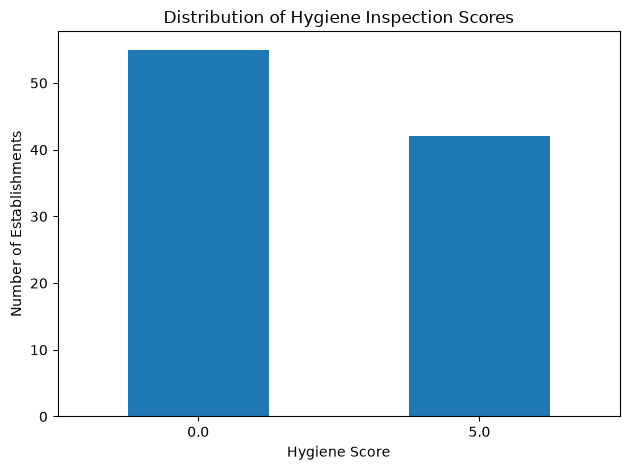

In [11]:
# Plot the Hygiene inspection score distribution
df["hygiene"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Hygiene Inspection Scores")
plt.xlabel("Hygiene Score")
plt.ylabel("Number of Establishments")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Step 9: Compare Inspection Score Components

We now compare the three FSA inspection score components:

- Hygiene
- Structural
- Confidence in Management

This helps us see whether one type of issue appears more frequently than the others in the current sample.


In [12]:
# Select the three inspection score columns
score_columns = [
    "hygiene",
    "structural",
    "confidence_in_management"
]

# Show summary statistics for the three scores
df[score_columns].describe()

,hygiene,structural,confidence_in_management
count,97.000000,97.000000,97.000000
mean,2.164948,3.247423,2.371134
std,2.490316,2.398050,2.509646
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,5.000000,0.000000
75%,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000


In [13]:
# Calculate the average value for each inspection score
average_scores = df[score_columns].mean()

average_scores

hygiene                     2.164948
structural                  3.247423
confidence_in_management    2.371134
dtype: float64

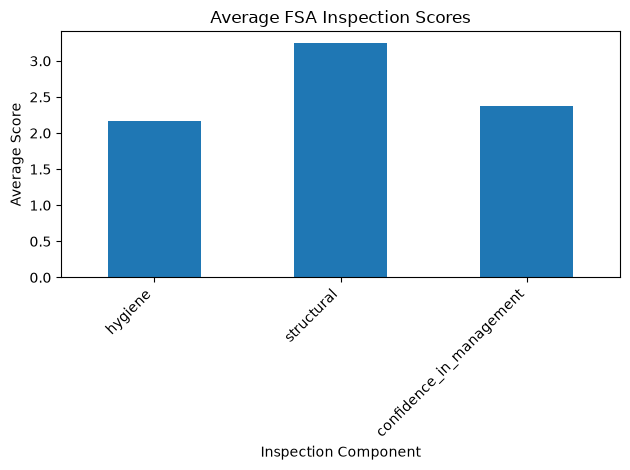

In [14]:
# Plot the average inspection score for each category
average_scores.plot(
    kind="bar"
)

plt.title("Average FSA Inspection Scores")
plt.xlabel("Inspection Component")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Step 10: Analyse Rating Dates

The `rating_date` column shows when each food hygiene rating was issued.

We will examine:

- the earliest rating date
- the latest rating date
- the number of ratings by year
- the number of ratings by month

This helps us understand how recent the inspection data is.

In [15]:
# Check the earliest and latest rating dates
print("Earliest rating date:", df["rating_date"].min())
print("Latest rating date:", df["rating_date"].max())

Earliest rating date: 2018-03-20 00:00:00
Latest rating date: 2026-07-25 00:00:00


In [16]:
# Extract the year from the rating date
df["rating_year"] = df["rating_date"].dt.year

# Count ratings by year
ratings_by_year = df["rating_year"].value_counts().sort_index()

ratings_by_year

rating_year
2018     1
2020     1
2021     2
2022     3
2023     6
2024    26
2025    41
2026    20
Name: count, dtype: int64

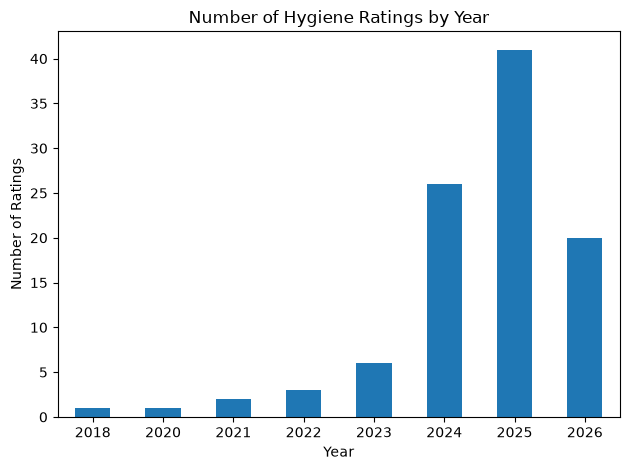

In [17]:
# Plot the number of ratings issued each year
ratings_by_year.plot(
    kind="bar"
)

plt.title("Number of Hygiene Ratings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Step 11: Analyse Rating Age

The age of a hygiene rating tells us how much time has passed since the establishment was inspected.

Older ratings may represent less up-to-date information than recent ratings.

We will calculate the number of days since each rating was issued and examine the distribution.

In [18]:
# Get today's date
today = pd.Timestamp.today().normalize()

# Calculate how many days have passed since each rating
df["rating_age_days"] = (
    today - df["rating_date"]
).dt.days

# Preview the result
df[
    ["business_name", "rating_date", "rating_age_days"]
].head()

,business_name,rating_date,rating_age_days
0,(ki:ts),2026-03-04,179
1,*Eatlife,2025-04-17,500
2,1 Hotel Mayfair,2026-01-21,221
3,1 Leicester Square Rooftop Bar and Restaurant,2026-01-09,233
4,1 Warwick,2025-04-29,488


In [19]:
# Show summary statistics for rating age
df["rating_age_days"].describe()

count     100.000000
mean      603.160000
std       492.648516
min        36.000000
25%       287.000000
50%       494.500000
75%       839.000000
max      3085.000000
Name: rating_age_days, dtype: float64

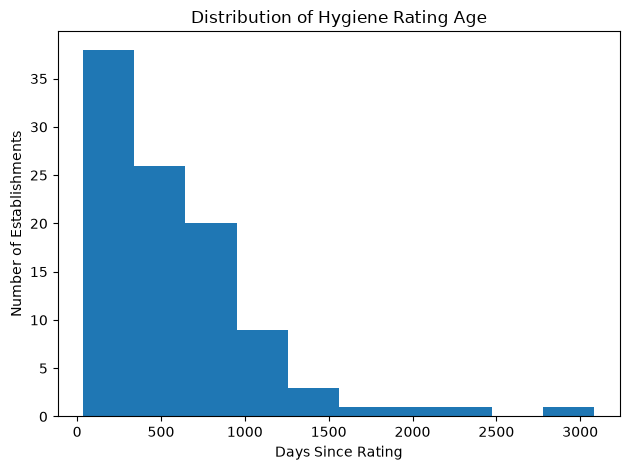

In [20]:
# Plot how old the hygiene ratings are
df["rating_age_days"].plot(
    kind="hist",
    bins=10
)

plt.title("Distribution of Hygiene Rating Age")
plt.xlabel("Days Since Rating")
plt.ylabel("Number of Establishments")
plt.tight_layout()

plt.show()

## Step 12: Analyse Establishment Locations

Latitude and longitude allow us to examine the geographic distribution of food establishments.

We will:

- check how many establishments have usable coordinates
- plot establishment locations
- identify whether geographic information may be useful for later analysis and feature engineering

Missing coordinates will remain excluded from the geographic plot rather than being artificially filled.

In [21]:
# Count businesses with and without usable coordinates
print("Missing latitude:", df["latitude"].isna().sum())
print("Missing longitude:", df["longitude"].isna().sum())

print(
    "Businesses with coordinates:",
    df[["latitude", "longitude"]].dropna().shape[0]
)

Missing latitude: 6
Missing longitude: 6
Businesses with coordinates: 94


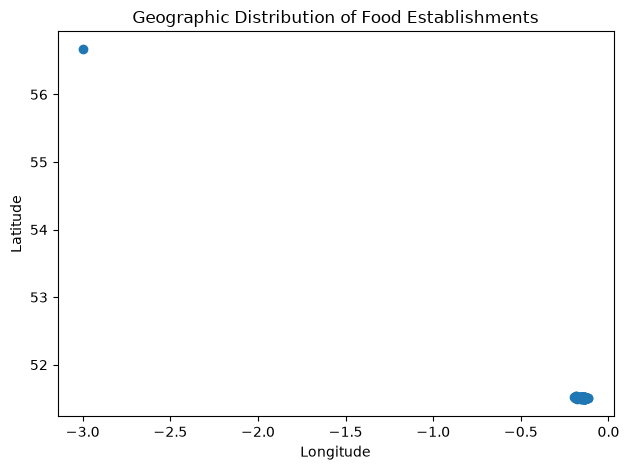

In [22]:
# Keep only businesses that have both latitude and longitude
geo_df = df.dropna(
    subset=["latitude", "longitude"]
)

# Plot establishment locations
plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"]
)

plt.title("Geographic Distribution of Food Establishments")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

plt.show()

## Step 13: Analyse Postcode Distribution

Postcodes can help us understand how establishments are distributed across different parts of the local area.

We will examine the most common postcodes and identify whether some locations contain multiple food establishments.

This will also help later when joining the FSA data with external geographic datasets such as ONS data.

In [23]:
# Count establishments by postcode
postcode_counts = df["postcode"].value_counts(dropna=False)

# Show the most common postcodes
postcode_counts.head(10)

postcode
W1U         2
SW1H 0AZ    2
W2 2RY      2
W1H         1
W1J 8DJ     1
WC2H 7NA    1
W1B 5LR     1
W1D 4DH     1
W1D 1LL     1
W2 4UW      1
Name: count, dtype: int64

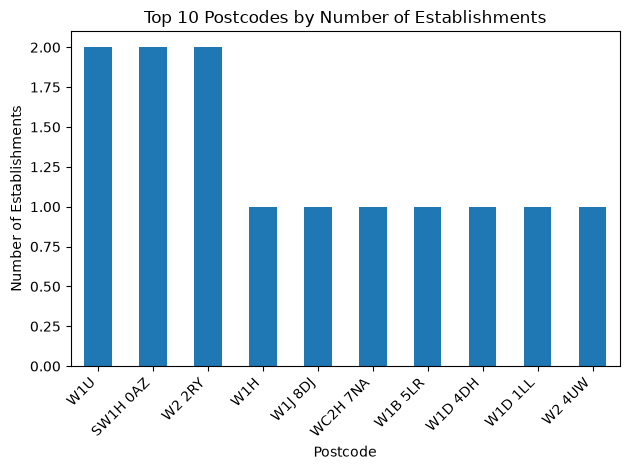

In [24]:
# Plot the 10 most common postcodes
postcode_counts.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Postcodes by Number of Establishments")
plt.xlabel("Postcode")
plt.ylabel("Number of Establishments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Step 14: Analyse Correlations Between Numerical Variables

Correlation measures how strongly two numerical variables move together.

A correlation close to:

- `1` indicates a strong positive relationship
- `0` indicates little linear relationship
- `-1` indicates a strong negative relationship

Identifiers such as `FHRSID` and `bronze_id` are excluded because their numerical values do not represent measurable characteristics.

In [25]:
# Select numerical variables that have analytical meaning
correlation_columns = [
    "hygiene",
    "structural",
    "confidence_in_management",
    "latitude",
    "longitude",
    "rating_age_days"
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,hygiene,structural,confidence_in_management,latitude,longitude,rating_age_days
hygiene,1.00,0.38,0.34,-0.10,0.09,-0.04
structural,0.38,1.00,0.22,0.07,-0.07,-0.03
confidence_in_management,0.34,0.22,1.00,-0.10,0.10,0.09
latitude,-0.10,0.07,-0.10,1.00,-1.00,-0.05
longitude,0.09,-0.07,0.10,-1.00,1.00,0.05
rating_age_days,-0.04,-0.03,0.09,-0.05,0.05,1.00


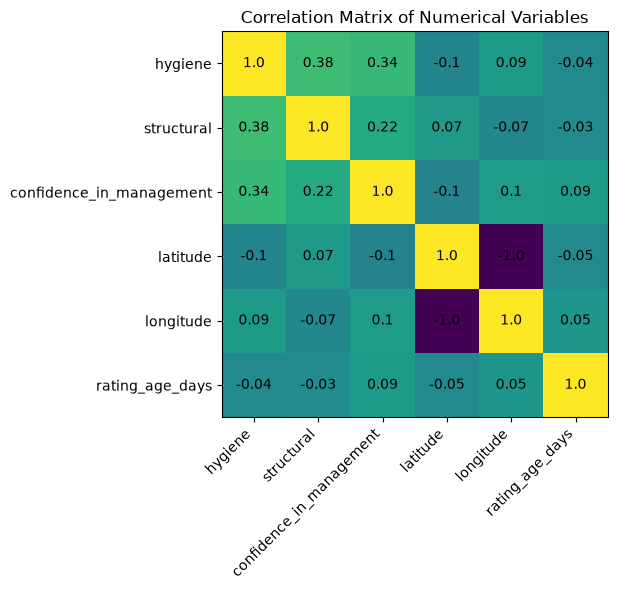

In [26]:
# Plot the correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(correlation_matrix)

# Add variable names to both axes
ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))

ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)

# Write each correlation value inside the matrix
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        ax.text(
            j,
            i,
            round(correlation_matrix.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## Step 15: Compare Inspection Scores by Business Type

We now compare the average inspection scores across different types of food businesses.

This can help identify whether certain business categories tend to have higher Hygiene, Structural, or Confidence in Management scores.

Lower inspection scores represent better inspection performance, while higher scores represent worse performance.

Because the current sample contains only hygiene rating `5`, these comparisons should be treated as exploratory rather than evidence of hygiene risk.

In [27]:
# Calculate average inspection scores for each business type
business_type_scores = (
    df.groupby("business_type")[
        [
            "hygiene",
            "structural",
            "confidence_in_management"
        ]
    ]
    .mean()
    .round(2)
)

business_type_scores

,hygiene,structural,confidence_in_management
business_type,,,
Hotel/bed & breakfast/guest house,2.50,2.50,3.33
Other catering premises,1.67,0.00,0.83
Pub/bar/nightclub,1.25,3.75,2.50
Restaurant/Cafe/Canteen,2.34,3.83,2.42
Retailers - other,2.27,2.73,2.73
Retailers - supermarkets/hypermarkets,0.00,5.00,0.00
School/college/university,0.00,0.00,0.00
Takeaway/sandwich shop,2.50,2.50,5.00


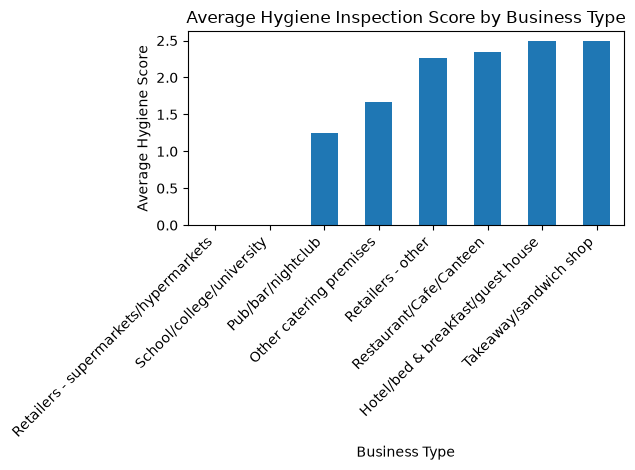

In [28]:
# Compare average Hygiene score by business type
business_type_scores["hygiene"].sort_values().plot(
    kind="bar"
)

plt.title("Average Hygiene Inspection Score by Business Type")
plt.xlabel("Business Type")
plt.ylabel("Average Hygiene Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Step 16: Statistical Comparison of Hygiene Scores by Business Type

We use a Kruskal-Wallis test to investigate whether hygiene inspection
scores differ significantly between business types.

Null hypothesis (H0):
There is no difference in hygiene scores between business types.

Alternative hypothesis (H1):
At least one business type has a different hygiene score distribution.

A significance level of 0.05 is used.

Because the current dataset is a small 100-row sample, the result will
be treated as exploratory rather than conclusive.

In [29]:
# scipy.stats provides statistical hypothesis tests
from scipy.stats import kruskal

# Remove rows where the hygiene score is missing
hygiene_data = df.dropna(
    subset=["business_type", "hygiene"]
)

# Create one hygiene-score group for each business type
groups = [
    group["hygiene"].values
    for name, group in hygiene_data.groupby("business_type")
]

# Perform the Kruskal-Wallis test
statistic, p_value = kruskal(*groups)

print("Kruskal-Wallis statistic:", round(statistic, 3))
print("P-value:", round(p_value, 4))

Kruskal-Wallis statistic: 4.299
P-value: 0.7448


In [30]:
# Interpret the statistical result using alpha = 0.05
alpha = 0.05

if p_value < alpha:
    print("Statistically significant difference detected.")
    print("Reject H0.")
else:
    print("No statistically significant difference detected.")
    print("Fail to reject H0.")

No statistically significant difference detected.
Fail to reject H0.


### Interpretation

The Kruskal-Wallis test produced a p-value of 0.7448.

Because this is greater than the significance level of 0.05, we fail to
reject the null hypothesis.

There is therefore no statistically significant evidence, within this
100-row sample, that hygiene inspection score distributions differ between
business types.

This result should be interpreted cautiously because several business
categories contain very small numbers of establishments and the sample is
limited to Westminster.

In [31]:
# Count establishments in each business type
business_type_sample_sizes = (
    hygiene_data["business_type"]
    .value_counts()
)

business_type_sample_sizes

business_type
Restaurant/Cafe/Canteen                  64
Retailers - other                        11
Other catering premises                   6
Hotel/bed & breakfast/guest house         6
Pub/bar/nightclub                         4
School/college/university                 3
Takeaway/sandwich shop                    2
Retailers - supermarkets/hypermarkets     1
Name: count, dtype: int64

## Step 18: Statistical Correlation Between Inspection Scores

We use Spearman correlation to test whether the FSA inspection score
components tend to increase or decrease together.

The test examines:

- Hygiene vs Structural
- Hygiene vs Confidence in Management
- Structural vs Confidence in Management

Null hypothesis (H0):
There is no association between the two inspection scores.

Alternative hypothesis (H1):
There is an association between the two inspection scores.

A significance level of 0.05 is used.

In [32]:
# spearmanr measures the strength and significance of a ranked relationship
from scipy.stats import spearmanr


# Hygiene vs Structural
pair_data = df[
    ["hygiene", "structural"]
].dropna()

correlation, p_value = spearmanr(
    pair_data["hygiene"],
    pair_data["structural"]
)

print("Spearman correlation:", round(correlation, 3))
print("P-value:", round(p_value, 4))

Spearman correlation: 0.38
P-value: 0.0001


In [33]:
# Interpret the statistical result
alpha = 0.05

if p_value < alpha:
    print("Statistically significant association.")
    print("Reject H0.")
else:
    print("No statistically significant association.")
    print("Fail to reject H0.")

Statistically significant association.
Reject H0.


### Interpretation

The Spearman correlation between Hygiene and Structural inspection scores
was 0.38, with a p-value of 0.0001.

Since the p-value is below the significance level of 0.05, the null
hypothesis is rejected.

This indicates a statistically significant moderate positive association
between Hygiene and Structural scores.

In this sample, establishments with poorer hygiene inspection performance
also tend to have poorer structural inspection performance.

This relationship represents an association and does not demonstrate
causation.

In [34]:
# Keep rows where both inspection scores are available
pair_data = df[
    ["hygiene", "confidence_in_management"]
].dropna()

# Calculate Spearman correlation
correlation, p_value = spearmanr(
    pair_data["hygiene"],
    pair_data["confidence_in_management"]
)

print("Spearman correlation:", round(correlation, 3))
print("P-value:", round(p_value, 4))

Spearman correlation: 0.337
P-value: 0.0007


In [35]:
alpha = 0.05

if p_value < alpha:
    print("Statistically significant association.")
    print("Reject H0.")
else:
    print("No statistically significant association.")
    print("Fail to reject H0.")

Statistically significant association.
Reject H0.


### Interpretation

The Spearman correlation between Hygiene and Confidence in Management
scores was 0.337, with a p-value of 0.0007.

Since the p-value is below 0.05, the null hypothesis is rejected.

This indicates a statistically significant positive association between
Hygiene and Confidence in Management scores.

Establishments with poorer hygiene inspection performance therefore also
tend to have poorer Confidence in Management scores in this sample.

This is an association and does not demonstrate causation.

In [36]:
# Keep rows where both inspection scores are available
pair_data = df[
    ["structural", "confidence_in_management"]
].dropna()

# Calculate Spearman correlation
correlation, p_value = spearmanr(
    pair_data["structural"],
    pair_data["confidence_in_management"]
)

print("Spearman correlation:", round(correlation, 3))
print("P-value:", round(p_value, 4))

Spearman correlation: 0.222
P-value: 0.0291


In [37]:
# Interpret the result using alpha = 0.05
alpha = 0.05

if p_value < alpha:
    print("Statistically significant association.")
    print("Reject H0.")
else:
    print("No statistically significant association.")
    print("Fail to reject H0.")

Statistically significant association.
Reject H0.


## Step 19: Summary of Inspection Score Associations

The three inspection score components are compared using Spearman
correlation.

This summary shows:

- the direction and strength of each association
- the p-value
- whether the relationship is statistically significant at alpha = 0.05

In [38]:
# Define the inspection-score pairs we want to compare
score_pairs = [
    ("hygiene", "structural"),
    ("hygiene", "confidence_in_management"),
    ("structural", "confidence_in_management")
]

results = []

# Calculate Spearman correlation for each pair
for score_1, score_2 in score_pairs:

    # Keep rows where both values are available
    pair_data = df[[score_1, score_2]].dropna()

    correlation, p_value = spearmanr(
        pair_data[score_1],
        pair_data[score_2]
    )

    results.append({
        "score_1": score_1,
        "score_2": score_2,
        "correlation": round(correlation, 3),
        "p_value": round(p_value, 4),
        "significant": p_value < 0.05
    })


# Turn the results into a table
correlation_results = pd.DataFrame(results)

correlation_results

,score_1,score_2,correlation,p_value,significant
0,hygiene,structural,0.380,0.0001,True
1,hygiene,confidence_in_management,0.337,0.0007,True
2,structural,confidence_in_management,0.222,0.0291,True


## Step 20: Identify Potential Target Leakage

Target leakage happens when a model is given information that would not realistically be available at prediction time, or information that directly reveals the target.

In this project, the target will be based on the food hygiene rating.

The FSA inspection score components:

- Hygiene
- Structural
- Confidence in Management

are produced as part of the same inspection process that generates the hygiene rating.

Because of this, using them to predict the hygiene rating could make the model unrealistically strong.

These variables will therefore be treated as potential leakage features and excluded from the main predictive model unless there is a clearly justified prediction scenario.

In [39]:
# Define variables that may cause target leakage
potential_leakage_features = [
    "hygiene",
    "structural",
    "confidence_in_management"
]

print("Potential leakage features:")

for feature in potential_leakage_features:
    print("-", feature)

Potential leakage features:
- hygiene
- structural
- confidence_in_management
